In [1]:
import warnings
warnings.filterwarnings("ignore")

IMPORTING LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import joblib

In [5]:
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

installing XGBOOST

In [ ]:
%pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 196.9 kB/s eta 0:06:06
   ---------------------------------------- 0.1/72.0 MB 219.0 kB/s eta 0:05:29
   ---------------------------------------- 0.1/72.0 MB 286.7 kB/s eta 0:04:11
   ---------------------------------------- 0.1/72.0 MB 286.7 kB/s eta 0:04:11
   ---------------------------------------- 0.1/72.0 MB 286.7 kB/s eta 0:04:11
   ---------------------------------------- 0.1/72.0 MB 302.7 kB/s eta 0:03:58
   ---------------------------------------- 0.2/72.0 MB 429.5 kB/s eta 0:02:48
   ---------------------------------------- 0.2/72.0 MB 437.6 kB/s eta 0:02:44
   ---------------------------------------- 0.2/72.0 MB 437.6 kB/s eta 0:02:44
   ------

In [8]:
import xgboost as xgb
xgb_available = True

In [9]:
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

In [10]:
df = pd.read_csv(r"C:\Users\DELL\Documents\4.1\diabetes prediction\diabetes.csv")

EXPLORATORY DATA ANALIYSIS

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
print(df.shape)

(768, 9)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


 Checking for missing values and replacing them with median values

In [17]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(df[zero_invalid] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [19]:
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zeros:
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


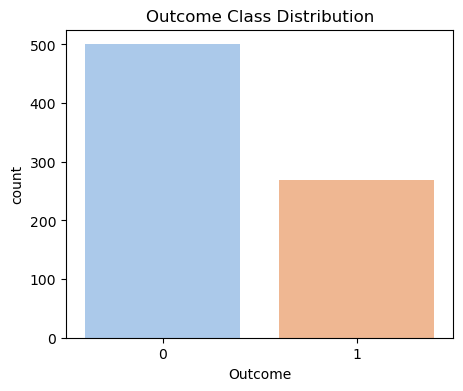

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [20]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Outcome", palette="pastel")
plt.title("Outcome Class Distribution")
plt.show()

df['Outcome'].value_counts(normalize=True)


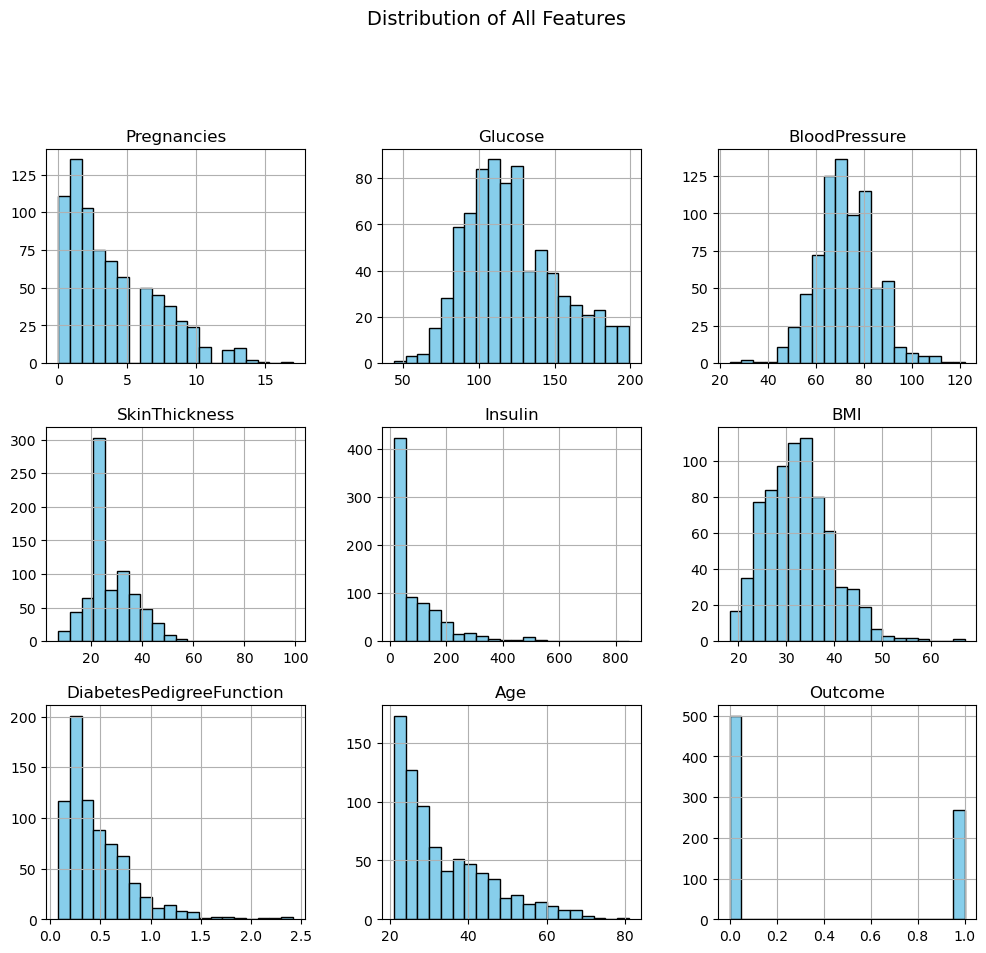

In [21]:
df.hist(figsize=(12,10), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Distribution of All Features", y=1.02, fontsize=14)
plt.show()


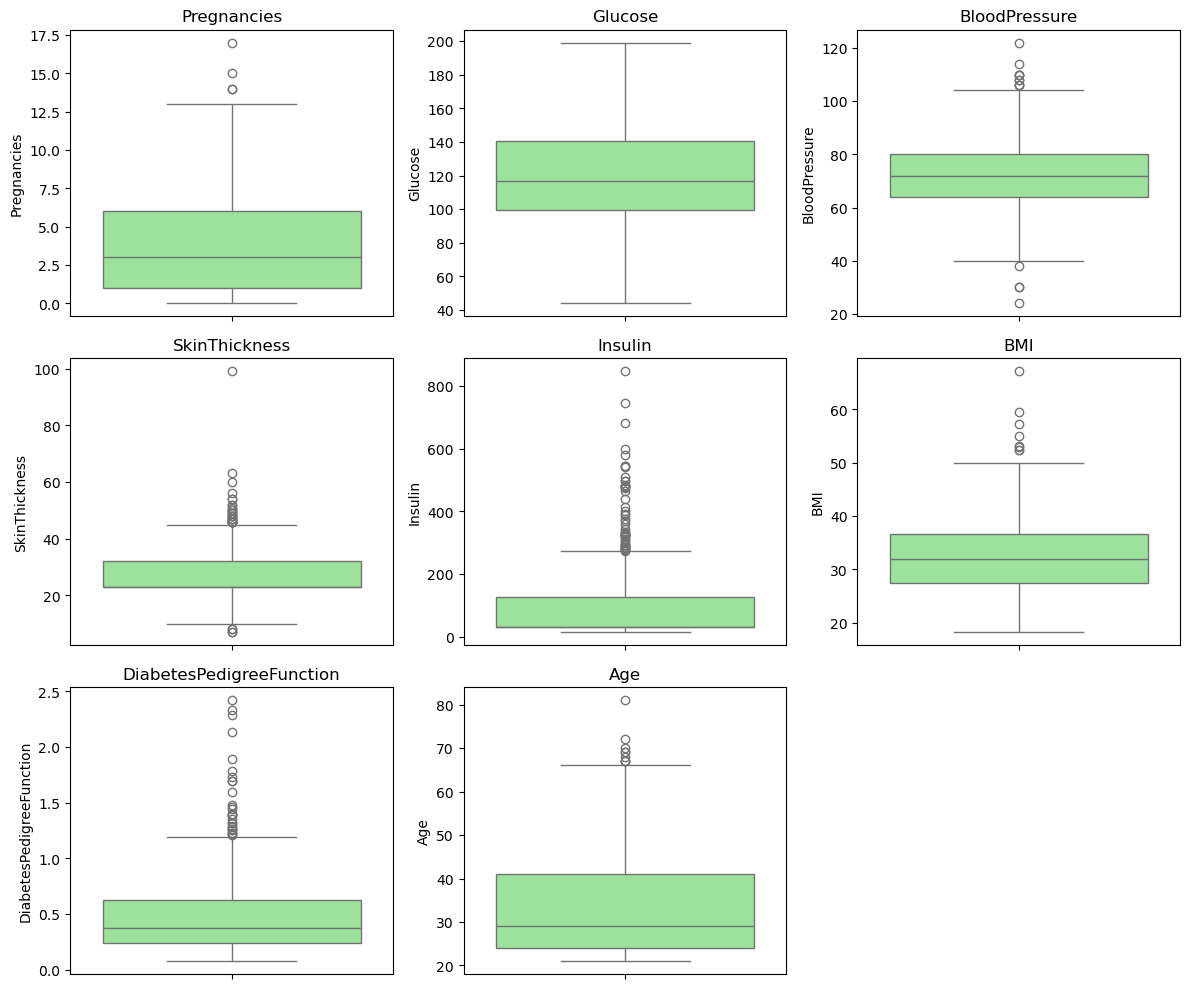

In [22]:
plt.figure(figsize=(12,10))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=col, color="lightgreen")
    plt.title(col)
plt.tight_layout()
plt.show()


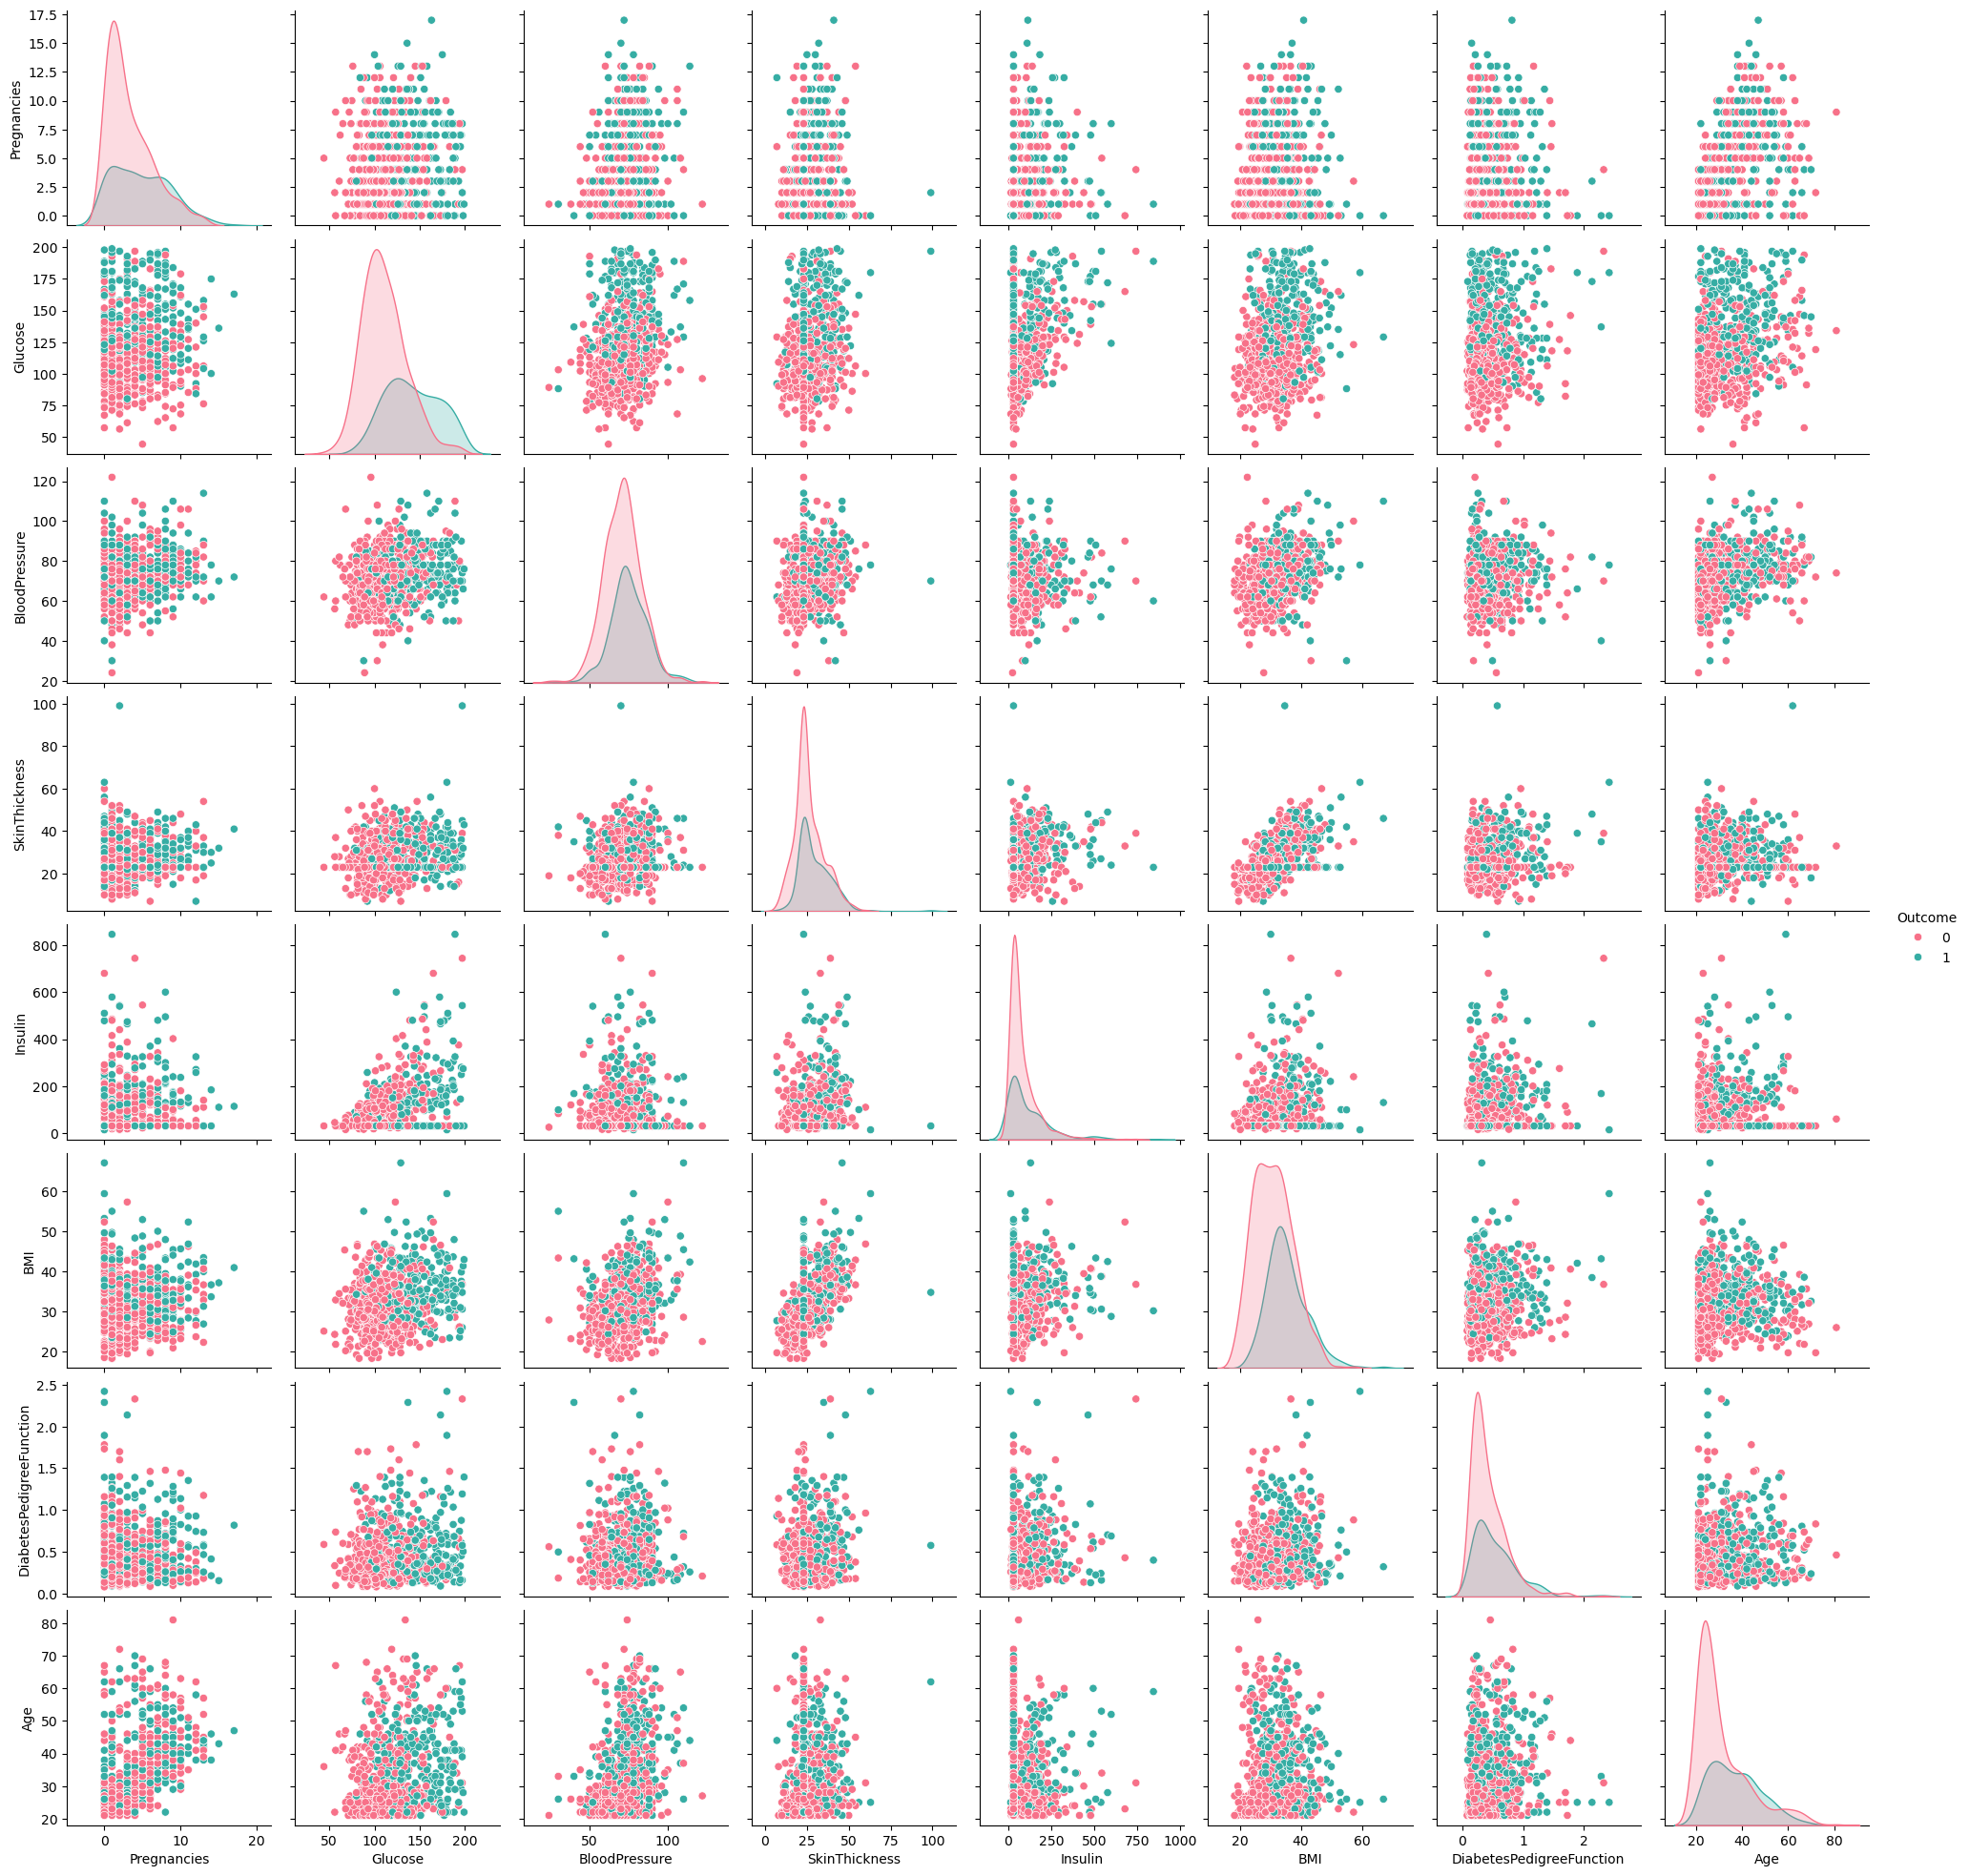

In [23]:
sns.pairplot(df, hue="Outcome", diag_kind="kde", palette="husl")
plt.show()


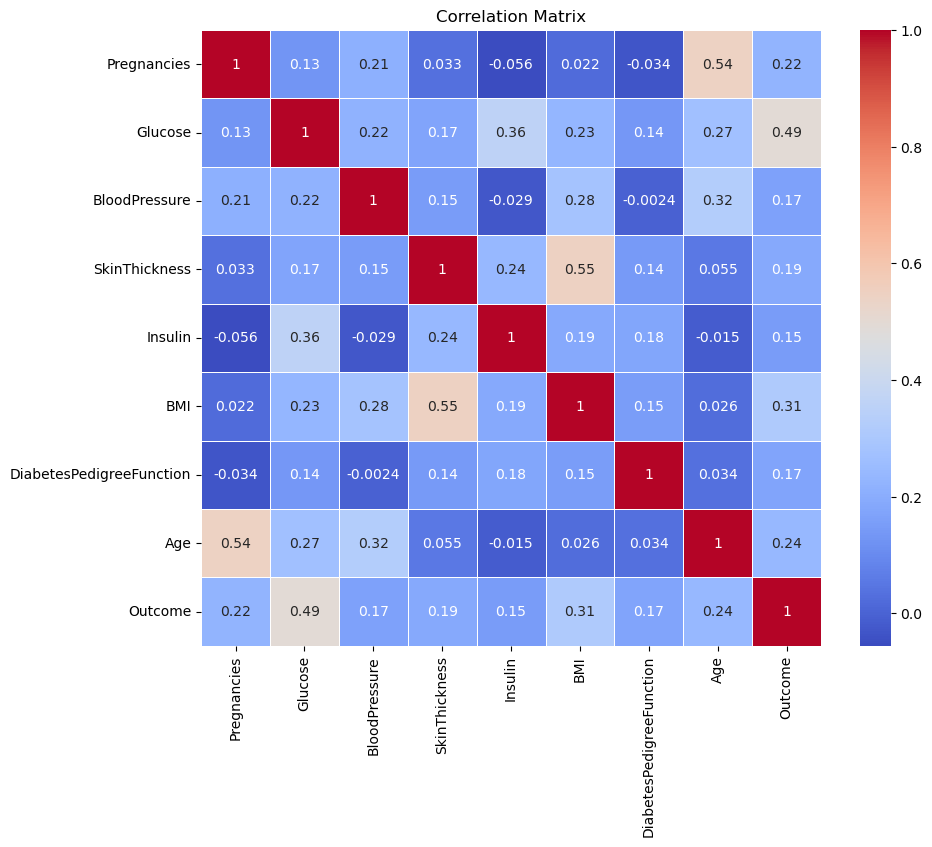

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


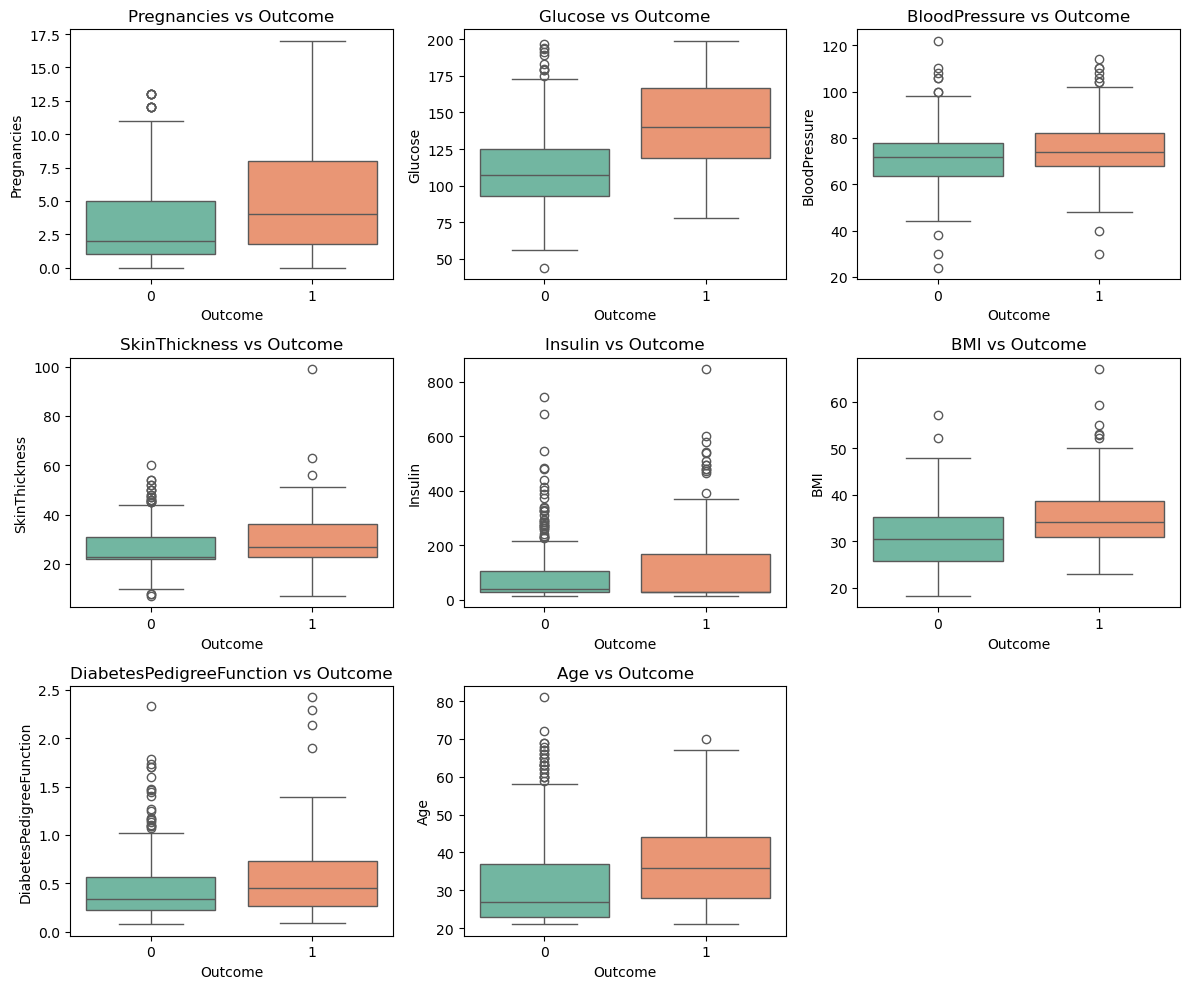

In [25]:
plt.figure(figsize=(12,10))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x="Outcome", y=col, palette="Set2")
    plt.title(f"{col} vs Outcome")
plt.tight_layout()
plt.show()


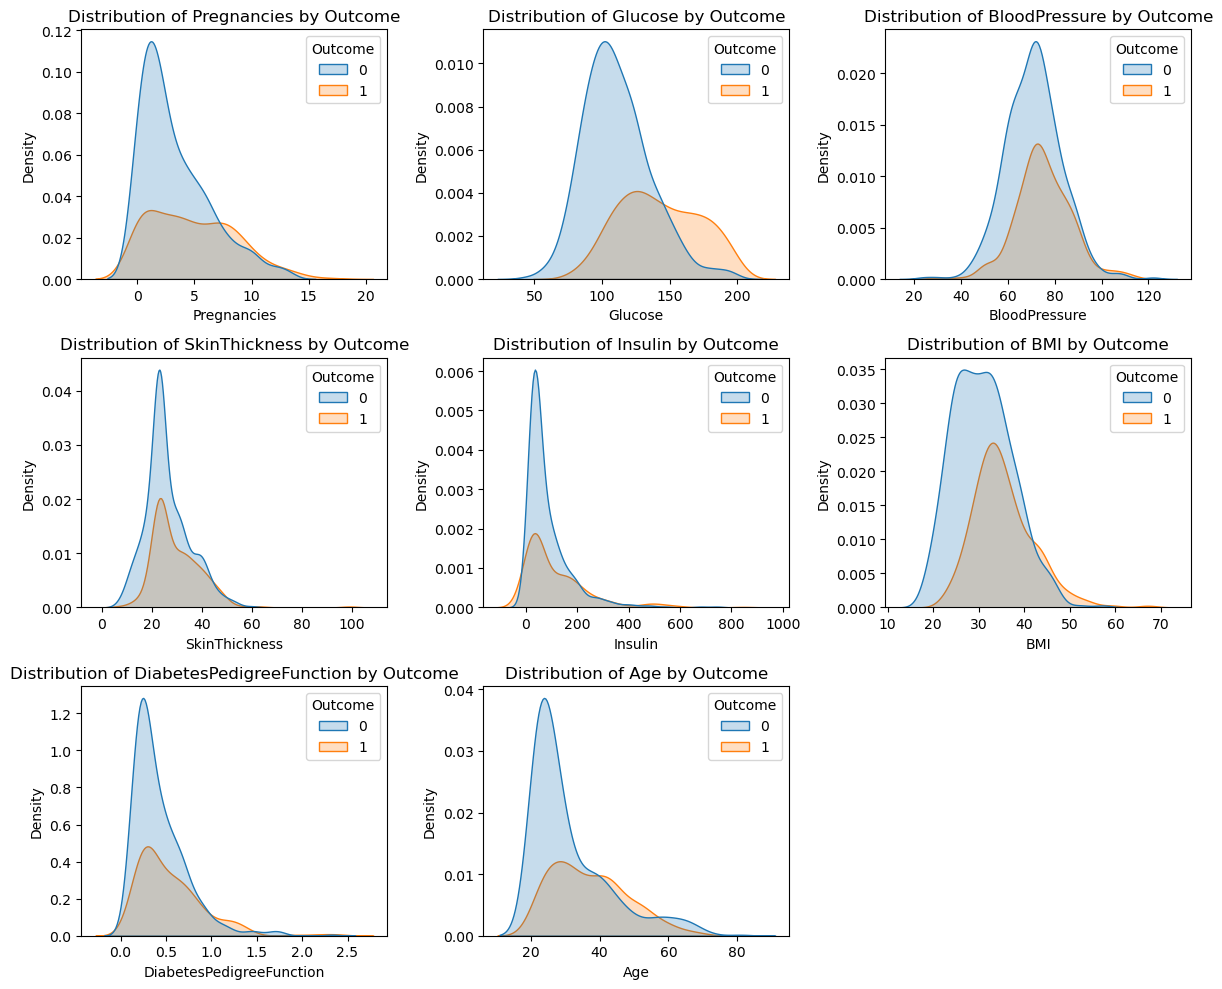

In [26]:
plt.figure(figsize=(12,10))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=col, hue="Outcome", fill=True)
    plt.title(f"Distribution of {col} by Outcome")
plt.tight_layout()
plt.show()


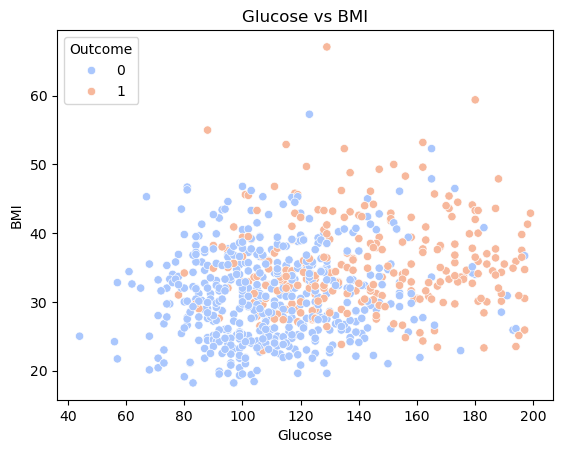

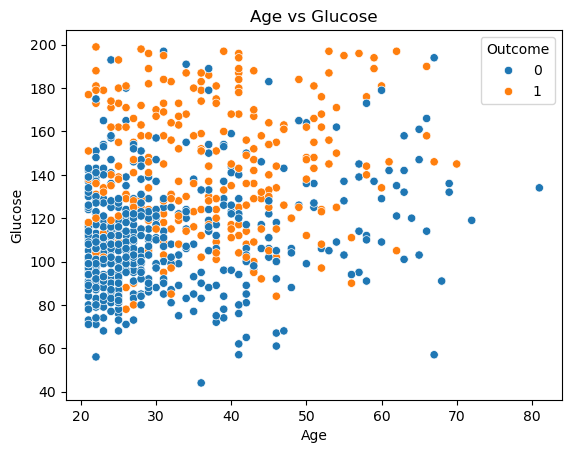

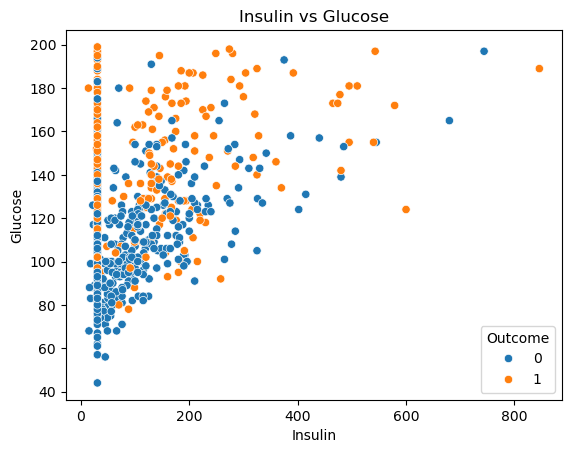

In [27]:
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome", palette="coolwarm")
plt.title("Glucose vs BMI")
plt.show()

sns.scatterplot(data=df, x="Age", y="Glucose", hue="Outcome")
plt.title("Age vs Glucose")
plt.show()

sns.scatterplot(data=df, x="Insulin", y="Glucose", hue="Outcome")
plt.title("Insulin vs Glucose")
plt.show()


In [28]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)][col]

for col in df.columns[:-1]:
    print(col, "outliers:", detect_outliers(col).count())


Pregnancies outliers: 4
Glucose outliers: 0
BloodPressure outliers: 14
SkinThickness outliers: 35
Insulin outliers: 49
BMI outliers: 8
DiabetesPedigreeFunction outliers: 29
Age outliers: 9


In [29]:
skew_kurt = pd.DataFrame({
    "Skewness": df.skew(),
    "Kurtosis": df.kurt()
})
skew_kurt


,Skewness,Kurtosis
Pregnancies,0.901674,0.159220
Glucose,0.535587,-0.257847
BloodPressure,0.141885,1.098239
SkinThickness,1.223057,4.716995
Insulin,2.693181,9.741075
BMI,0.601059,0.921296
DiabetesPedigreeFunction,1.919911,5.594954
Age,1.129597,0.643159
Outcome,0.635017,-1.600930


DATA PREPROCESSING

In [31]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
X[zero_invalid] = X[zero_invalid].replace(0, np.nan)

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

SPLITTING THE DATA SET

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

APPLYING SMOTE

In [35]:
sm = SMOTE(random_state=42)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_over.value_counts())

Before SMOTE: Outcome
0    400
1    214
Name: count, dtype: int64
After SMOTE: Outcome
0    400
1    400
Name: count, dtype: int64


TRAINING THE MODEL

LOGISTIC REGRESSION

In [38]:
log_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

log_clf.fit(X_train_over, y_train_over)
log_pred = log_clf.predict(X_test)
log_proba = log_clf.predict_proba(X_test)[:,1]

ROC CURVE

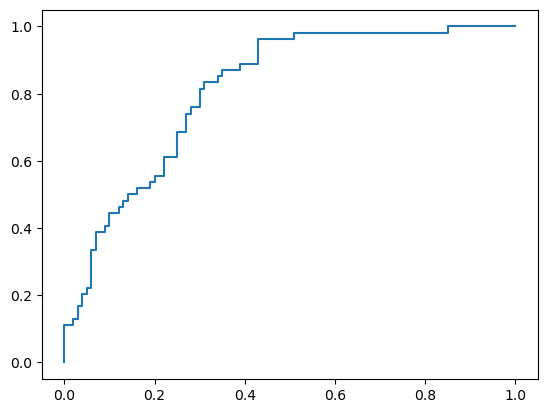

In [40]:
fpr, tpr, _ = roc_curve(y_test, log_proba)
plt.plot(fpr, tpr, label=f"Logistic (AUC={roc_auc_score(y_test, log_proba):.3f})")

RANDOM FOREST

In [42]:
rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_clf.fit(X_train_over, y_train_over)
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:,1]

ROC CURVE

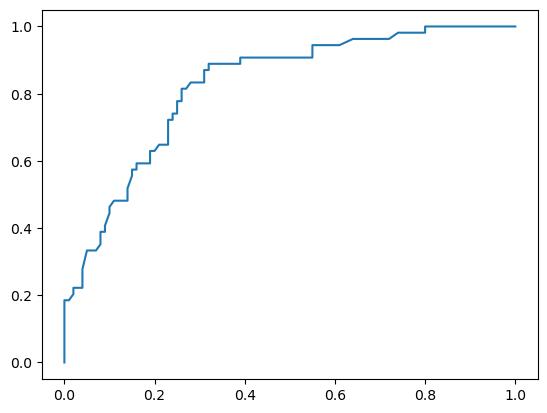

In [44]:
fpr, tpr, _ = roc_curve(y_test, rf_proba)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_proba):.3f})")

XGBOOST

In [46]:
try:
    import xgboost as xgb
    xgb_available = True
except ImportError:
    xgb_available = False


In [47]:
if xgb_available:
    xgb_clf = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", xgb.XGBClassifier(
            eval_metric="logloss",
            use_label_encoder=False,
            random_state=42
        ))
    ])
    xgb_clf.fit(X_train_over, y_train_over)
    xgb_pred = xgb_clf.predict(X_test)
    xgb_proba = xgb_clf.predict_proba(X_test)[:,1]

ROC CURVE

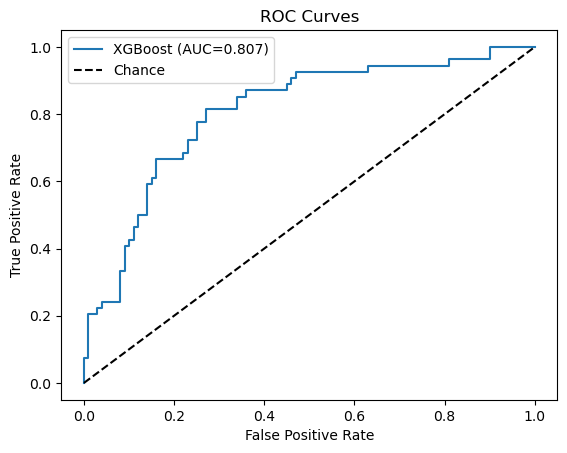

In [49]:
if xgb_available:
    fpr, tpr, _ = roc_curve(y_test, xgb_proba)
    plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_proba):.3f})")

plt.plot([0,1], [0,1], 'k--', label="Chance")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

FEATURE IMPORTANCE

In [51]:
rf_model = rf_clf.named_steps["clf"]
X_test_processed = preprocessor.transform(X_test)

perm = permutation_importance(
    rf_model, X_test_processed, y_test,
    n_repeats=20, random_state=42
)

importance_df = pd.DataFrame({
    "feature": numeric_features,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
1,Glucose,0.071753
7,Age,0.030195
5,BMI,0.014610
2,BloodPressure,0.004870
4,Insulin,0.000974
3,SkinThickness,-0.009091
6,DiabetesPedigreeFunction,-0.012013
0,Pregnancies,-0.013961


BAR CHART

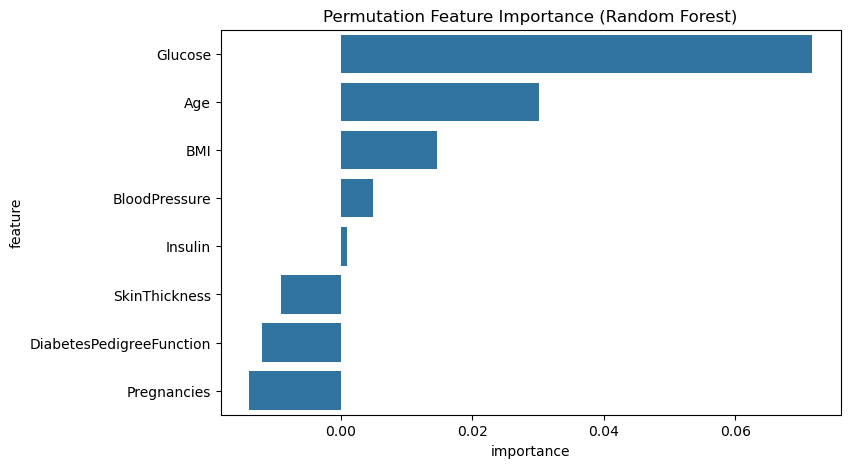

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, y="feature", x="importance")
plt.title("Permutation Feature Importance (Random Forest)")
plt.show()

FINDING AND SAVING THE BEST MODEL

In [55]:
model_metrics = {
    "Logistic Regression": roc_auc_score(y_test, log_proba),
    "Random Forest": roc_auc_score(y_test, rf_proba)
}

if xgb_available:
    model_metrics["XGBoost"] = roc_auc_score(y_test, xgb_proba)

model_metrics


{'Logistic Regression': 0.8124074074074074,
 'Random Forest': 0.8237962962962964,
 'XGBoost': 0.807037037037037}

In [109]:
best_model_name = max(model_metrics, key=model_metrics.get)
print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Random Forest


In [113]:
import joblib

if best_model_name == "Logistic Regression":
    best_model = log_clf
elif best_model_name == "Random Forest":
    best_model = rf_clf
elif best_model_name == "XGBoost":
    best_model = xgb_clf

joblib.dump(best_model, "best_diabetes_model.joblib")
print(f"Saved {best_model_name} as best_diabetes_model.joblib")


Saved Random Forest as best_diabetes_model.joblib


In [115]:
joblib.dump(best_model, "best_diabetes_model.joblib")

['best_diabetes_model.joblib']

In [117]:
import os
os.getcwd()


'C:\\Users\\DELL'